<a href="https://colab.research.google.com/github/riggij-sys/Jake-Riggi-Repository/blob/main/coding_homework_8_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Jake Riggi

*Neur 265*

**April 6th**

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
#this cell imports relevant modules

In [107]:
url='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv'
fear_traces=np.loadtxt(url, delimiter=',')
url2='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv'
extinction_predictors=np.loadtxt(url2, delimiter=',')
shock_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv', delimiter = ',').astype(int)
tone_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv', delimiter = ',').astype(int)
#this cell creaates data frames based on csv files inputted, time when a shock happened, and time when a tone happened were also uplaoded as numpy dataframes

In [108]:
conditioning_traces=fear_traces[:10458]

extinction_traces=fear_traces[10457:]
#this cell creates 2 arrays as instructe.Becasue numpy indexing starts from 0 is necessary to index the number before the sample we want, making me think to index at 10457. However, in calcium imaging part 2 the size of the array is 10458, so I indexed there

In [109]:
print(conditioning_traces.size)
print(extinction_traces.size)
print(conditioning_traces.shape)
print(extinction_traces.shape)
#prints both the size and shapes of each of the arrays created in the previous cell. Only size was askedd for but shape is relevant for next cell.

658854
895293
(10458, 63)
(14211, 63)


In [110]:
time_conditioning=np.linspace(0,10458/15,10458)
time_extinction=np.linspace(0,14211/15,14211)
#using the time and fps created time variables to eventually use in plotting and other things using the linspace method as seen in class

there are 64 ROI's. I know this because in the instructions it says ROI's correspond to rows an there are 64 rows in our dataframe, but indexing starts at 0 so there is an extra ROI



the total length of time for the conidtion session is 10456/15=697.06 seconds or 11.61 minutes

the total length  of time for the extinction session is 14210/15=947.33 seconds or 15.79 minutes

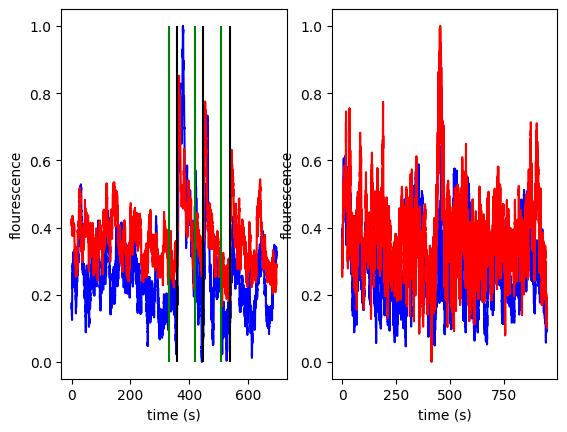

In [111]:
fig, ax = plt.subplots(1,2)
ax[0].plot(time_conditioning, conditioning_traces[:,0], color='blue')
ax[0].plot(time_conditioning, conditioning_traces[:,1], color='red')
ax[0].set_ylabel('flourescence')
ax[0].set_xlabel('time (s)')
ax[0].vlines(shock_index,0,1, color='black')
ax[0].vlines(tone_index,0,1, color='green')

ax[1].plot(time_extinction,extinction_traces[:,0], color='blue')
ax[1].set_ylabel('flourescence')
ax[1].set_xlabel('time (s)')
ax[1].plot(time_extinction,extinction_traces[:,1], color='red')
#This cell creates our 2 subplots of our two ROIs during both extinction and conditioning. The first subplot contains black lines indicating when the shock happened and green lines indicating when the tone happened.


In the first ROI, in both the conditioning and extinction traces there seems to be at least 1 spike.

For our second ROI, it is spiking during the conditioning phase after the tone and shock are presented, however there doesn't seem to be much spiking during the exctinction phase.

It it difficult to see on these charts, but it looks like ROI 2 responds more than ROI 1 during conditioning, but less than ROI 1 during extinction, meaning there would nt be a relationship between the amount a cell responds during conditioning and the amount a cell responds during extinction.

In [112]:
from pandas import DataFrame as df
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import identity, log
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF

shock_array_conditioning = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array_conditioning[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array_conditioning[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array_conditioning[i] = 1
  else:
    shock_array_conditioning[i] = 0

tone_array_conditioning=np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array_conditioning[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array_conditioning[i] = 1
  else:
    tone_array_conditioning[i] = 0

predictorsConditioning['shock onset'] = shock_array_conditioning
r_model_conditioning = np.zeros(63)

for i in range(63):
  predictorsConditioning = df(data={'Intercept': np.ones_like(tone_array_conditioning), 'tone onset': tone_array_conditioning})
  trace_temp_conditioning = conditioning_traces[:,i]
  predictors_conditioning= sm.GLM(trace_temp_conditioning, predictorsConditioning, family=Poisson())
  predictors_conditioning_results = predictors_conditioning.fit()
  predicted_trace_conditioning = predictors_conditioning_results.predict()
  r3_conditioning = pearsonr(trace_temp_conditioning, predicted_trace_conditioning)
  r_index_conditioning[i] = r3_conditioning.statistic

#this cell creates a distribution of r value, a distributuion of how different our model is from our actual flourescence for each ROI

In [113]:
shock_array_extinction = np.zeros(14211)
for i in range(14211):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array_extinction[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array_extinction[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array_extinction[i] = 1
  else:
    shock_array_extinction[i] = 0

tone_array_extinction = np.zeros(14211)
for i in range(14211):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array_extinction[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array_extinction[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array_extinction[i] = 1
  else:
    tone_array_extinction[i] = 0


predictorsExtinction['shock onset'] = shock_array_extinction
r_model_extinction = np.zeros(63)

for i in range(63):
  predictorsExtinction = df(data={'Intercept': np.ones_like(tone_array_extinction), 'tone onset': tone_array_extinction})
  trace_temp_extinction = extinction_traces[:,i]
  extinction_predictors = sm.GLM(first_trace_extinction, predictorsExtinction, family=Poisson())
  extinction_predictors_results = extinction_predictors.fit()
  predicted_trace_extinction = extinction_predictors_results.predict()
  r3_extinction = pearsonr(trace_temp_extinction, predicted_trace_extinction)
  r_index_extinction[i] = r3_extinction.statistic
#this cell gets our r value distribution for our extinction ROIs


In [114]:
print(pearsonr(r_index_conditioning,r_index_extinction))
#this prints a correlation coefficient (r values) between our r value distribution during conditioning and our r value distribution during extinction

PearsonRResult(statistic=np.float64(0.09969544825529086), pvalue=np.float64(0.4369217372878462))


Text(0, 0.5, 'correlation between model and observed trace during extinction')

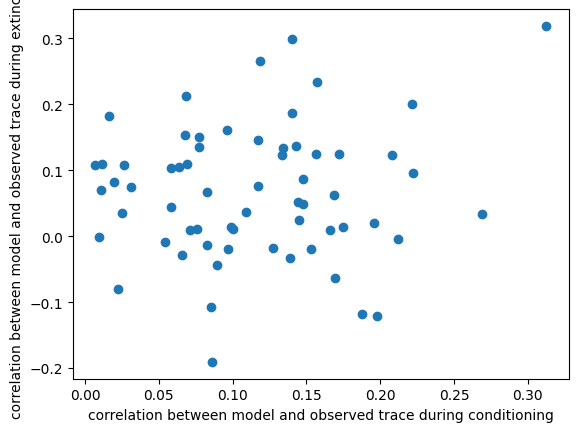

In [115]:
plt.scatter(r_index_conditioning,r_index_extinction)
plt.xlabel('correlation between model and observed trace during conditioning')
plt.ylabel('correlation between model and observed trace during extinction')
#this cell creates a scatterplot with our r value distribution during conditioning n our x axis and our r value distrubion duirng extinction on the y axis. this means for every ROI we are seeing how well our model correlates with actual flourescence during conditioning and extinction

there is not very much correlation anyhwere in this graph, and the p value for our correlation is quite high, making me beleive there is no correlation between a cell responding strongly during conditioning and a cell responding strongly during extinction.